/Users/utsabchakraborty/Documents/Edureka_May2026/LangGraph/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


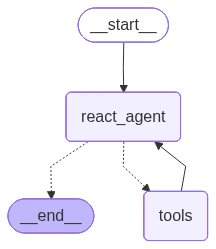


Agent reasoning...


Agent reasoning...


FINAL AGENT OUTPUT

content='\n                Add 20 and 30.\n                Then multiply the result by 5.\n                ' additional_kwargs={} response_metadata={} id='00c79ba4-bc45-4aec-be48-ea85f5174073'
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 84, 'total_tokens': 134, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_d2f048fbf1', 'id': 'chatcmpl-Dg7jv8fLRYHoBHjYKpIrrY4xXSGCF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019e309a-951f-74b2-8716-87df3a1e5999-0' tool_calls=[{'name': 'add', 'args': {'a': 20, 'b': 30}, 'id': 'call_UMoCPhmlNS6jLM7953AiaBl2', 'type': 'to

In [1]:
"""
=============================================================
FILE 29 — REACT AGENT
=============================================================

CONCEPTS TAUGHT
----------------
1. ReAct Pattern
2. Thought → Action → Observation
3. Tool Calling
4. Iterative Reasoning
5. Autonomous Agents
6. Agent Loops
7. Tool-Based Planning
8. Multi-Step Reasoning
9. Dynamic Execution
10. Agentic AI

CORE IDEA
-----------
The AI reasons,
uses tools,
observes outputs,
then continues reasoning.

FLOW
-----
Thought
   ↓
Tool Action
   ↓
Observation
   ↓
New Thought
   ↓
Repeat

REAL WORLD USE CASES
---------------------
- Autonomous research agents
- Coding agents
- Browser agents
- AI copilots
- AI operators
"""

# ============================================================
# STEP 1 — IMPORTS
# ============================================================

import os

from dotenv import load_dotenv

from typing_extensions import TypedDict
from typing import Annotated

from langgraph.graph.message import add_messages

from langgraph.graph import StateGraph, START, END

from langgraph.prebuilt import ToolNode, tools_condition

from IPython.display import Image, display

# ============================================================
# STEP 2 — LOAD ENV VARIABLES
# ============================================================

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# STEP 3 — INITIALIZE LLM
# ============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

# ============================================================
# STEP 4 — DEFINE TOOLS
# ============================================================

def multiply(a: int, b: int) -> int:
    """
    Multiply two numbers.
    """
    return a * b


def add(a: int, b: int) -> int:
    """
    Add two numbers.
    """
    return a + b

tools = [multiply, add]

# ============================================================
# STEP 5 — BIND TOOLS
# ============================================================

llm_with_tools = llm.bind_tools(tools)

# ============================================================
# STEP 6 — DEFINE STATE
# ============================================================

class State(TypedDict):
    messages: Annotated[list, add_messages]

# ============================================================
# STEP 7 — AGENT NODE
# ============================================================

def react_agent(state: State):

    """
    Main reasoning node.
    """

    print("\nAgent reasoning...\n")

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

# ============================================================
# STEP 8 — BUILD GRAPH
# ============================================================

builder = StateGraph(State)

builder.add_node(
    "react_agent",
    react_agent
)

builder.add_node(
    "tools",
    ToolNode(tools)
)

# ============================================================
# STEP 9 — DEFINE EDGES
# ============================================================

builder.add_edge(
    START,
    "react_agent"
)

builder.add_conditional_edges(
    "react_agent",
    tools_condition
)

builder.add_edge(
    "tools",
    "react_agent"
)

# ============================================================
# STEP 10 — COMPILE GRAPH
# ============================================================

graph = builder.compile()

# ============================================================
# STEP 11 — VISUALIZE GRAPH
# ============================================================

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

# ============================================================
# STEP 12 — RUN AGENT
# ============================================================

result = graph.invoke(
    {
        "messages": [
            (
                "human",
                """
                Add 20 and 30.
                Then multiply the result by 5.
                """
            )
        ]
    }
)

# ============================================================
# STEP 13 — PRINT MESSAGES
# ============================================================

print("\nFINAL AGENT OUTPUT\n")

for msg in result["messages"]:
    print(msg)